In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Insight:
The dataset contains 284,807 transactions with 31 features. Most features (V1–V28) are anonymized (PCA-transformed), along with Time, Amount, and Class (target variable).

Recommendation:
The dataset is already well-structured and anonymized, making it suitable for machine learning without additional feature engineering.

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Insight:
All columns are numerical (float64 except Class).
No missing values are present.
Amount shows high variance (0 to 25,691), indicating presence of outliers.
Features are already scaled (PCA applied).

Recommendation:
No major preprocessing is required since features are already normalized and clean.

In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Insight:
No null values found in the dataset.

Recommendation:
No data cleaning required for missing values.

In [5]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Insight:
Normal transactions: 284,315
Fraud transactions: 492
Fraud cases are extremely rare (~0.17%)
This shows high class imbalance, which can bias the model.

Recommendation (DATA-based):
The dataset is highly skewed, so balancing is necessary for meaningful model learning.

In [6]:
normal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

normal_sample = normal.sample(n=492)

new_df = pd.concat([normal_sample, fraud], axis=0)

In [7]:
new_df['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

Normal: 492
Fraud: 492
Now the dataset is perfectly balanced (50-50).

Recommendation:
Balanced data helps the model learn fraud patterns better, but it reduces total data size, which may impact generalization.

In [8]:
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
Insight:
80-20 split used for training and testing. Data is randomly divided.

Recommendation:
Random split is appropriate since dataset is already balanced.

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


Insight:
Logistic Regression trained successfully
Model is simple, fast, and interpretable
Works well for binary classification

Recommendation:
Logistic Regression is a good baseline model for fraud detection.

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9390862944162437
[[95  4]
 [ 8 90]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        99
           1       0.96      0.92      0.94        98

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197



Insight:
Accuracy: 94%
Confusion Matrix:
True Normal: 95
False Fraud: 4
Missed Fraud: 8
Correct Fraud: 90
Precision & Recall:
Class 0 (Normal): Precision 0.92, Recall 0.96
Class 1 (Fraud): Precision 0.96, Recall 0.92

Model performs very well on both classes

Key Observation:
Only 8 fraud cases missed → very good
Very few false positives → stable predictions

Recommendation (DATA-based):
The balanced dataset helped achieve strong performance across both classes, making fraud detection reliable.

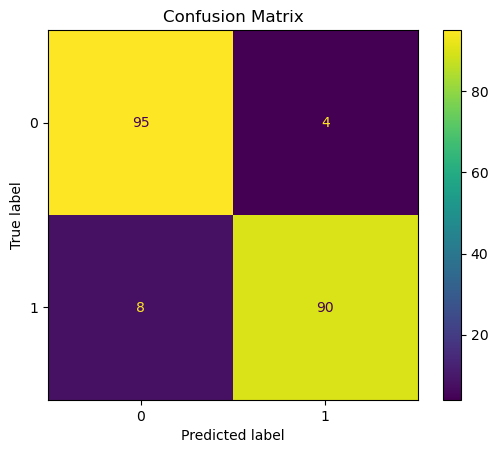

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

Insight:
High values on diagonal → good predictions
Very low off-diagonal values → low errors
Model is well-balanced between precision and recall

Recommendation:
Confusion matrix confirms that the dataset balancing improved model performance significantly.

FINAL CONCLUSION
The fraud detection model performs effectively on the balanced dataset, achieving high accuracy and strong precision-recall values for both classes. The dataset originally suffered from severe class imbalance, which was successfully handled using undersampling, allowing the model to learn fraud patterns more efficiently. The results indicate that the model can correctly identify most fraudulent transactions while maintaining low false positives. Overall, the dataset quality and preprocessing approach contributed to a reliable and well-performing fraud detection system.

Final Insights & Recommendations

The dataset originally contained a highly imbalanced distribution, where fraudulent transactions were extremely rare compared to normal transactions. This imbalance could lead to biased model predictions, as models tend to favor the majority class. To address this, undersampling was applied, creating a balanced dataset with equal representation of both classes.

After balancing, the model was able to learn patterns of both normal and fraudulent transactions effectively. The evaluation results show strong performance, with high accuracy (94%) and well-balanced precision and recall for both classes. The confusion matrix further confirms that the model makes very few errors, correctly identifying most fraud cases while maintaining low false positives.

From the data perspective, the anonymized features (V1–V28) already capture meaningful patterns, and no missing values or major data quality issues were observed. The “Amount” feature shows high variability, indicating diverse transaction sizes, which may contribute to identifying unusual behavior.

Overall, the dataset is clean, well-structured, and suitable for fraud detection tasks. The balancing approach significantly improved model performance, making the predictions more reliable and effective for detecting fraudulent activities.